In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

In [3]:
df = pd.read_csv("train.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
df = df[["Survived", "Pclass", "Sex", "Age", "SibSp", "Parch", "Fare", "Embarked"]]
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


In [5]:
df.isnull().sum()

Survived      0
Pclass        0
Sex           0
Age         177
SibSp         0
Parch         0
Fare          0
Embarked      2
dtype: int64

In [6]:
df["Age"] = df["Age"].fillna(df["Age"].median())
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])


In [7]:
df["Sex"] = df["Sex"].map({"male": 0, "female": 1})

df = pd.get_dummies(df, columns = ["Embarked"], drop_first = True)

In [8]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S
0,0,3,0,22.0,1,0,7.2500,False,True
1,1,1,1,38.0,1,0,71.2833,False,False
2,1,3,1,26.0,0,0,7.9250,False,True
3,1,1,1,35.0,1,0,53.1000,False,True
4,0,3,0,35.0,0,0,8.0500,False,True


In [9]:
X = df.drop("Survived", axis = 1)
y = df["Survived"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [10]:
model = LogisticRegression(max_iter = 200)

model.fit(X_train, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",200
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'l

In [11]:
y_pred = model.predict(X_test)
y_pred

array([0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1,
       0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0,
       1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0,
       0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1,
       0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0,
       0, 1, 1])

In [12]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
# Overall correctness
print("Accuracy:", accuracy_score(y_test, y_pred))
# Error breakdown (TN, FP, FN, TP)
print(confusion_matrix(y_test, y_pred))
# Detailed metrics
print(classification_report(y_test, y_pred))

Accuracy: 0.8100558659217877
[[90 15]
 [19 55]]
              precision    recall  f1-score   support

           0       0.83      0.86      0.84       105
           1       0.79      0.74      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179



In [13]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": model.coef_[0]
})
feature_importance.sort_values(by = "Coefficient", ascending = False)

,Feature,Coefficient
1,Sex,2.591284
5,Fare,0.002580
2,Age,-0.030555
4,Parch,-0.108087
6,Embarked_Q,-0.112915
3,SibSp,-0.295037
7,Embarked_S,-0.400240
0,Pclass,-0.937748


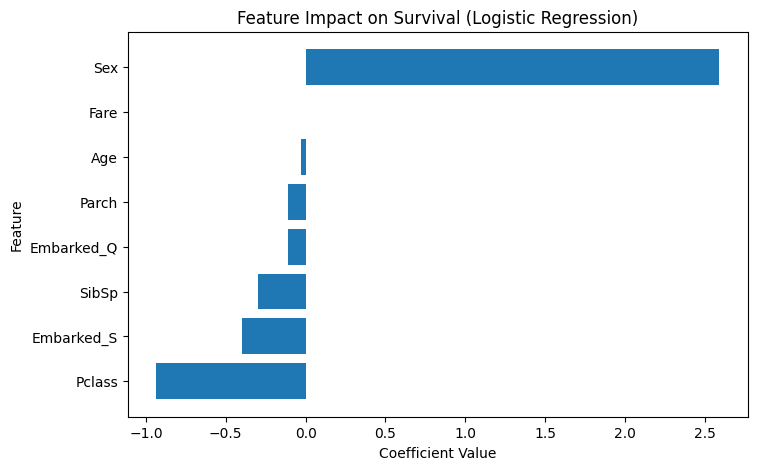

In [14]:
feature_importance = feature_importance.sort_values(by = "Coefficient")
# Sets graph size and makes visualization readable
plt.figure(figsize=(8,5))
# Creates horizontal bars for x and y axis
plt.barh(feature_importance["Feature"], feature_importance["Coefficient"])
plt.title("Feature Impact on Survival (Logistic Regression)")
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")
plt.show()

In [15]:
print("Model Training Complete")

print("Training Accuracy:", model.score(X_train, y_train))
print("Test Accuracy:", model.score(X_test, y_test))

print("\nFeature Importance (Top 5):")
print(feature_importance.tail(5)[::-1])

Model Training Complete
Training Accuracy: 0.800561797752809
Test Accuracy: 0.8100558659217877

Feature Importance (Top 5):
      Feature  Coefficient
1         Sex     2.591284
5        Fare     0.002580
2         Age    -0.030555
4       Parch    -0.108087
6  Embarked_Q    -0.112915


In [16]:
from sklearn.ensemble import RandomForestClassifier
# Builds 100 decision trees and combines their votes
rf_model = RandomForestClassifier(n_estimators=100, random_state = 42)

rf_model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [17]:
rf_pred = rf_model.predict(X_test)
rf_pred

array([0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1,
       0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0,
       1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0,
       0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1,
       0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0,
       0, 1, 1])

In [18]:
print("Logistic Regression Accuracy:", model.score(X_test, y_test))
print("Random Forest Accuracy:", rf_model.score(X_test, y_test))

Logistic Regression Accuracy: 0.8100558659217877
Random Forest Accuracy: 0.7988826815642458


In [19]:
rf_importance = pd.DataFrame({"Feature": X_train.columns, "Importance": rf_model.feature_importances_})
rf_importance.sort_values(by = "Importance", ascending = False)

,Feature,Importance
5,Fare,0.273568
1,Sex,0.268369
2,Age,0.253454
0,Pclass,0.080003
3,SibSp,0.054522
4,Parch,0.037680
7,Embarked_S,0.022740
6,Embarked_Q,0.009663


In [20]:
# ----- MODULE 4 START -----
from google import genai
import os

In [21]:
client = genai.Client(api_key=os.getenv("GEMINI_API_KEY"))


In [22]:
sample = X_test.iloc[0].to_dict()
prediction = model.predict([X_test.iloc[0]])[0]
prompt = f"""Passenger data: {sample} Prediction (0 = died, 1 = survived): {prediction} Explian this prediction in simple terms"""

response = client.models.generate_content(model = "gemini-2.5-flash", contents = prompt)
print(response.text)

c:\Users\admin\OneDrive\Documents\AI Projects\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


This passenger was predicted to have **died**, mainly because of two very important reasons based on common patterns seen on the Titanic:

1.  **Sex (Male):** The passenger was male (`Sex: 0`). On the Titanic, the rule was "women and children first," so men generally had a much lower chance of surviving compared to women.
2.  **Class (Third Class):** The passenger was in Third Class (`Pclass: 3`). These passengers were often in the lower parts of the ship and had more difficulty getting to the lifeboats, leading to much lower survival rates compared to those in First or Second Class.

Being a young adult (28) and paying a lower fare are also consistent with the challenges faced by third-class male passengers. Combining these strong factors, the model predicted this passenger would not have survived.


In [23]:
client = genai.Client(api_key = os.environ["GEMINI_API_KEY"])

In [24]:
response = client.models.generate_content(model = "gemini-2.5-flash", contents = "Explain Titanic survival in one sentence")
print(response.text)

Survival on the Titanic was primarily determined by social class, gender, and age, disproportionately favoring first-class passengers, women, and children due to the "women and children first" protocol and proximity to lifeboats.


In [25]:
prompt = """You are an AI assistant. Return exactly the following JSON format. {"risk_level": "", "summary": "", "recommendation": []}
A Titanic passenger: Age: 30, Sex: Female, passenger Class: 1, Fare: 80. Return only valid JSON."""
response = client.models.generate_content(
    model = "gemini-2.5-flash",
    contents = prompt
)
print(response.text)

```json
{"risk_level": "Very Low", "summary": "This passenger's risk of not surviving the Titanic disaster was very low. As a female, she was highly prioritized for lifeboat access under the 'women and children first' policy. Her first-class status further increased her chances, providing better access to lifeboats and crew assistance compared to lower-class passengers. Her age of 30 placed her in a demographic often associated with higher survival rates within the prioritized groups.", "recommendation": ["Prioritize boarding a lifeboat as soon as instructed, as per 'women and children first' policy.", "Remain calm and follow all instructions from the ship's crew and officers.", "Utilize the access advantages of first class to reach higher decks and lifeboat stations efficiently."]}
```


In [26]:
import json
clean_text = response.text.replace("```json", "").replace("```", "").strip()
# Reads the JSON from a string
data = json.loads(clean_text)
print(data)

{'risk_level': 'Very Low', 'summary': "This passenger's risk of not surviving the Titanic disaster was very low. As a female, she was highly prioritized for lifeboat access under the 'women and children first' policy. Her first-class status further increased her chances, providing better access to lifeboats and crew assistance compared to lower-class passengers. Her age of 30 placed her in a demographic often associated with higher survival rates within the prioritized groups.", 'recommendation': ["Prioritize boarding a lifeboat as soon as instructed, as per 'women and children first' policy.", "Remain calm and follow all instructions from the ship's crew and officers.", 'Utilize the access advantages of first class to reach higher decks and lifeboat stations efficiently.']}


In [27]:
print(data["risk_level"])
print(data["summary"])

print("\nRecommendations")

for recommendation in data["recommendation"]:
    print("-", recommendation)

Very Low
This passenger's risk of not surviving the Titanic disaster was very low. As a female, she was highly prioritized for lifeboat access under the 'women and children first' policy. Her first-class status further increased her chances, providing better access to lifeboats and crew assistance compared to lower-class passengers. Her age of 30 placed her in a demographic often associated with higher survival rates within the prioritized groups.

Recommendations
- Prioritize boarding a lifeboat as soon as instructed, as per 'women and children first' policy.
- Remain calm and follow all instructions from the ship's crew and officers.
- Utilize the access advantages of first class to reach higher decks and lifeboat stations efficiently.


In [28]:
from google.genai import types
import warnings

# Configure the client with a nested retry options object to avoid server error
client = genai.Client(
    http_options=types.HttpOptions(
        retry_options=types.HttpRetryOptions(
            attempts=5,        # Number of times to try
            initial_delay=2.0,  # Base delay in seconds
            max_delay=60.0,    # Cap on the exponential backoff
        )
    )
)

warnings.filterwarnings("ignore", category=UserWarning, module="sklearn")

results = []
for i in range(5):
    sample = X_test.iloc[i]
    # Prepare readable inputs for Gemini
    sex = "male" if sample["Sex"] == 0 else "female"
    pclass_map = {1: "First Class", 2: "Second Class", 3: "Third Class"}
    pclass = pclass_map[sample["Pclass"]]
    # ML prediction (rained model)
    ml_prediction = model.predict([sample])[0]
    # Build prompt for Gemini
    prompt = f"""You are an AI assistant.
    A Titanic passenger has the following details.
    Age: {sample["Age"]}
    Sex: {sex}
    Passenger Class: {pclass}
    Fare: {sample["Fare"]}

    Explain this passenger's chances of survival.
    Return valid JSON in this format:
    {{
        "risk_level": ""
        "summary": ""
        "recommendations": []
    }}"""
    # Call Gemini
    response = client.models.generate_content(
        model = "gemini-2.5-flash",
        contents = prompt
    )
    # Clean response
    clean_text = response.text.replace("```json", "").replace("```","").strip()
    # Convert to Python dict
    data = json.loads(clean_text)
    results.append(data)
# Output
print(results[4])

{'risk_level': 'Medium', 'summary': "This passenger, a 14-year-old female in Third Class, faced a complex set of factors influencing her survival chances. Her gender and age were significant advantages, as the 'women and children first' policy was heavily prioritized during the evacuation. This meant she would generally be given preference for lifeboat spots. However, her Third Class status presented considerable disadvantages. Third Class cabins were often located deep within the ship, making access to the upper decks and lifeboats difficult and time-consuming. There were also reports of barriers and confusion that could hinder their evacuation. While Third Class women and children had significantly better survival rates than Third Class men, their chances were still lower than those in First or Second Class. Overall, her youth and gender provided a strong protective factor, partially offsetting the challenges posed by her passenger class.", 'recommendations': ['Prioritize reaching th

In [29]:
def build_prompt(sample, prediction):
    sex = "male" if sample["Sex"] == 0 else "female"
    pclass_map = {1: "First Class", 2: "Second Class", 3: "Third Class"}
    pclass = pclass_map[sample["Pclass"]]
    prompt = f"""
    You are an AI assistant.
    A Titanic passenger has the following details.
    Age: {sample["Age"]}
    Sex: {sex}
    Passenger Class: {pclass}
    Fare: {sample["Fare"]}

    Explain this passenger's chances of survival.
    Return valid JSON in this format:
    {{
        "risk_level": ""
        "ml_interpretation": ""
        "llm_reasoning": ""
        "recommendations": []
    }}"""
    return prompt

In [30]:
sample = X_test.iloc[0]

prediction = model.predict([sample])[0]

prompt = build_prompt(sample, prediction)
print(prompt)


    You are an AI assistant.
    A Titanic passenger has the following details.
    Age: 28.0
    Sex: male
    Passenger Class: Third Class
    Fare: 15.2458

    Explain this passenger's chances of survival.
    Return valid JSON in this format:
    {
        "risk_level": ""
        "ml_interpretation": ""
        "llm_reasoning": ""
        "recommendations": []
    }


In [31]:
import json

def get_llm_response(prompt):
    response = client.models.generate_content(model="gemini-2.5-flash", contents=prompt)

    clean_text = (response.text.replace("```json", "").replace("```", "").strip())

    return json.loads(clean_text)

In [32]:
def analyse_passenger(index):
    sample = X_test.iloc[index]

    prediction = model.predict([sample])[0]
    prompt = build_prompt(sample, prediction)
    result = get_llm_response(prompt)

    return result

In [33]:
output = analyse_passenger(0)
print(output)

{'risk_level': 'Extremely High', 'ml_interpretation': "An AI model trained on the Titanic dataset would predict a very low probability of survival for this passenger. The combination of being male and in Third Class are historically the strongest negative indicators for survival chances due to the 'women and children first' policy and the limited access and distant location of third-class accommodations relative to the lifeboats.", 'llm_reasoning': "This passenger, an adult male in Third Class, faced extremely poor odds of survival during the Titanic disaster. \n1.  **Sex (Male):** The 'women and children first' policy was heavily enforced, leading to significantly lower survival rates for adult men compared to women and children, particularly in the lower classes.\n2.  **Passenger Class (Third Class):** Third-class passengers had the lowest survival rates of all classes. Their cabins were often on the lowest decks, farthest from the lifeboats, and access to the upper decks could be ch

In [34]:
print("=" * 50)
print("Titanic Passenger Analysis")
print("=" * 50)

print(f"Risk level: {output['risk_level']}")
print(f"ML Interpretation: {output['ml_interpretation']}")
print(f"LLM Reasoning: {output['llm_reasoning']}")

print("\nRecommendations:")
for recommendation in output['recommendations']:
    print(f"- {recommendation}")

Titanic Passenger Analysis
Risk level: Extremely High
ML Interpretation: An AI model trained on the Titanic dataset would predict a very low probability of survival for this passenger. The combination of being male and in Third Class are historically the strongest negative indicators for survival chances due to the 'women and children first' policy and the limited access and distant location of third-class accommodations relative to the lifeboats.
LLM Reasoning: This passenger, an adult male in Third Class, faced extremely poor odds of survival during the Titanic disaster. 
1.  **Sex (Male):** The 'women and children first' policy was heavily enforced, leading to significantly lower survival rates for adult men compared to women and children, particularly in the lower classes.
2.  **Passenger Class (Third Class):** Third-class passengers had the lowest survival rates of all classes. Their cabins were often on the lowest decks, farthest from the lifeboats, and access to the upper decks 

In [35]:
index = 7
sample = X_test.iloc[index]

prediction = model.predict([sample])[0]

actual = y_test.iloc[index]

print(f"Model Prediction: {prediction}")
print(f"Acual Outcome: {actual}")

print("The model predicted correctly") if prediction == actual else print("The model predicted incorrectly")

Model Prediction: 0
Acual Outcome: 0
The model predicted correctly


In [36]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc}")

cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix")
print(cm)

print("\nClassification Report")
print(classification_report(y_test, y_pred))

Accuracy: 0.8100558659217877

Confusion Matrix
[[90 15]
 [19 55]]

Classification Report
              precision    recall  f1-score   support

           0       0.83      0.86      0.84       105
           1       0.79      0.74      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179



In [37]:
feature_importance = pd.DataFrame({"Feature": X_test.columns, "Importance": model.coef_[0]})
feature_importance = feature_importance.sort_values(by = "Importance", ascending = False)

print(feature_importance)

      Feature  Importance
1         Sex    2.591284
5        Fare    0.002580
2         Age   -0.030555
4       Parch   -0.108087
6  Embarked_Q   -0.112915
3       SibSp   -0.295037
7  Embarked_S   -0.400240
0      Pclass   -0.937748


In [38]:
lr_importance = pd.DataFrame({"Feature": X_test.columns, "LR_Importance": model.coef_[0]})
lr_importance = lr_importance.sort_values(by = "LR_Importance", ascending = False)

rf_importance = pd.DataFrame({"Feature": X_test.columns, "RF_Importance": rf_model.feature_importances_})
rf_importance = rf_importance.sort_values(by = "RF_Importance", ascending = False)

comparision = pd.merge(lr_importance, rf_importance, on="Feature")
print(comparision)

      Feature  LR_Importance  RF_Importance
0         Sex       2.591284       0.268369
1        Fare       0.002580       0.273568
2         Age      -0.030555       0.253454
3       Parch      -0.108087       0.037680
4  Embarked_Q      -0.112915       0.009663
5       SibSp      -0.295037       0.054522
6  Embarked_S      -0.400240       0.022740
7      Pclass      -0.937748       0.080003


In [39]:
lr_pred = model.predict(X_test)
rf_pred = rf_model.predict(X_test)

from sklearn.metrics import accuracy_score

lr_acc = accuracy_score(y_test, lr_pred)
rf_acc = accuracy_score(y_test, rf_pred)

print(f"Logistic Regression Accuracy: {lr_acc}")
print(f"Random Forest Accuracy: {rf_acc}")

if lr_acc > rf_acc:
    print("\nSelected Model: Logistic Regression")
    final_model = model
else:
    print("Selected Model: Random Forest")
    final_model = rf_model

Logistic Regression Accuracy: 0.8100558659217877
Random Forest Accuracy: 0.7988826815642458

Selected Model: Logistic Regression


In [40]:
import json

def get_llm_response(prompt):
    try:
        response = client.models.generate_content(model = "gemini-2.5-flash", contents = prompt)
        clean_text = (response.text.replace("```json", "").replace("```", "").strip())
        return json.loads(clean_text)
    except Exception as e:
        return {
            "risk_level": "Unknown",
            "summary": "Unable to generate explaination",
            "recommendations": [],
            "error": str(e)
        }

In [41]:
if __name__ == "main": 
    output = analyse_passenger(0)
    print(output)

In [43]:
import joblib
joblib.dump(final_model, "model.pkl")
joblib.dump(model, "lr_model.pkl")
joblib.dump(rf_model, "rf_model.pkl")

['rf_model.pkl']